# Model Training notebook

# 1. Decision tree algorithm

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")
print(df.shape)

(2520798, 70)


In [4]:
import numpy as np

def validate_dataset(df):

    print("=" * 50)
    print("DATASET VALIDATION")
    print("=" * 50)

    assert "Label" in df.columns, "Label column missing."

    assert "Label_encoded" not in df.columns, \
        "Data leakage detected (Label_encoded)."

    assert df.isnull().sum().sum() == 0, \
        "Missing values detected."

    numeric = df.select_dtypes(include=[np.number])

    assert np.isinf(numeric).sum().sum() == 0, \
        "Infinite values detected."

    assert df.duplicated().sum() == 0, \
        "Duplicate rows detected."

    print("Shape:", df.shape)

    print("Validation passed.")
validate_dataset(df)

DATASET VALIDATION
Shape: (2520798, 70)
Validation passed.


In [5]:
X = df.drop(columns=["Label"])

y = df["Label"]

In [6]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    shuffle=True,
    random_state=42
)

In [8]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [10]:
tree = DecisionTreeClassifier(
    random_state = 42
)

tree.fit(X_train_tree , y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
y_pred_tree = tree.predict(X_test_tree)

In [12]:
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=encoder.classes_
))

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.80      0.84      0.82       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.98      0.99      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       0.86      0.86      0.86         7
                  PortScan       0.99      0.98      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.75      0.73      0.74       294
Web Attack � Sql Injection       1.00      0.75

In [13]:
joblib.dump(tree, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

In [14]:
joblib.dump(encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

In [15]:
accuracy = accuracy_score(y_test, y_pred_tree)

print(f"{accuracy:.8f}")

0.99806411


# 2. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# creating the model
rf = RandomForestClassifier(
    n_estimators = 100 ,
    random_state = 42 ,
    n_jobs = -1
)
# training the model
rf.fit(X_train , y_train)
# predections
y_pred_rf = rf.predict(X_test) 
# evaluation 
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names = encoder.classes_
    )
)

Print the metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average="weighted")
recall = recall_score(y_test, y_pred_rf, average="weighted")
f1 = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1-score : {f1:.6f}")

Accuracy : 0.998229
Precision: 0.998191
Recall   : 0.998229
F1-score : 0.998201


Confusion Matrix

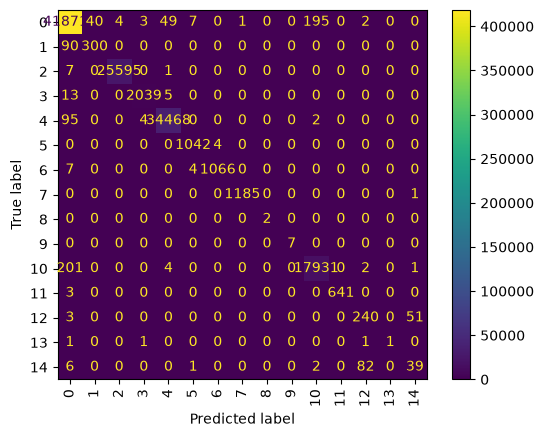

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    xticks_rotation=90
)

plt.show()

In [ ]:
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance.head(20)

,Feature,Importance
40,Packet Length Variance,0.078096
13,Bwd Packet Length Std,0.073907
39,Packet Length Std,0.064687
52,Avg Bwd Segment Size,0.054808
10,Bwd Packet Length Max,0.043134
54,Subflow Fwd Bytes,0.036258
5,Total Length of Bwd Packets,0.033359
12,Bwd Packet Length Mean,0.033241
38,Packet Length Mean,0.031183
4,Total Length of Fwd Packets,0.029998


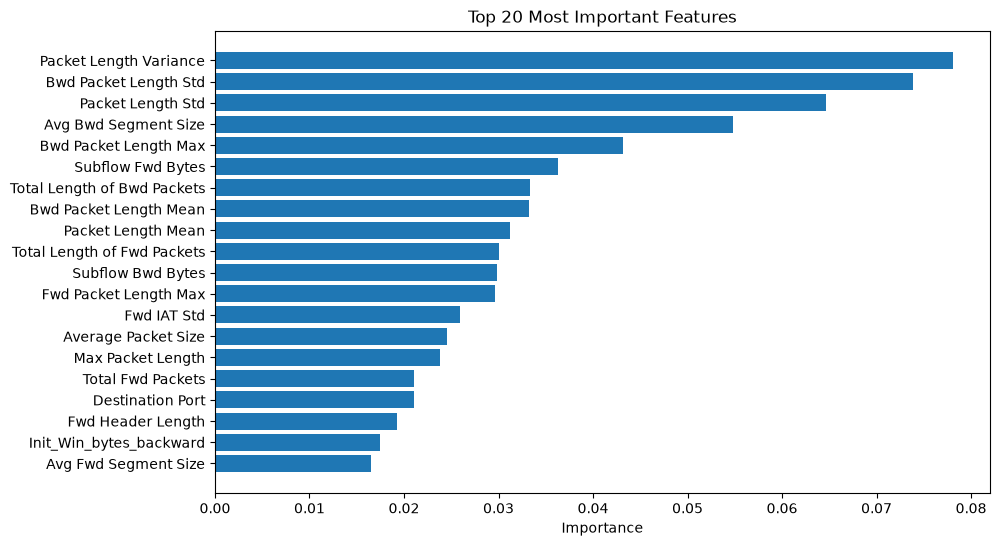

In [ ]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Most Important Features")
plt.show()

In [ ]:
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

# 3. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

Creating the model

In [ ]:
lr = LogisticRegression(
    max_iter = 1000,
    random_state = 42,
)

Training the model

In [ ]:
lr.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

# 3. Support Vector Machine

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state = 42
)

# training the model
svm.fit(X_train , y_train)

# predict the results
y_pred_svm = svm.predict(X_test)

# displaying the report

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names = encoder.classes_
    )
)

NameError: name 'X_train' is not defined

Print the metrics :

In [ ]:
accuracy = accuracy_score(y_test , y_pred_svm)
precision = precision_score(y_test , y_pred_svm , average="weighted")
recall = recall_score(y_test , y_pred_svm , average="weighted")
f1 = f1_score(y_test , y_pred_svm , average="weighted")

print(f"Accuracy : {accuracy:.6}")
print(f"Precision : {precision:.6}")
print(f"Recall : {recall:.6}")
print(f"F1 : {f1:.6}")


Confusion matrix :

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    xtricks_rotation=90
)